In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Client özetini yükle (küçük dosya, RAM sorunu yok)
client_df = pd.read_csv('../data/client_ozet.csv')
print(f"Client sayısı: {len(client_df)}")
print(client_df.head())

Client sayısı: 1219
   client_id     toplam  islem  hata
0          0  780919.67  12795   188
1          1  367921.37  10073   156
2          2  372360.27  10612   131
3          3  292935.46   6001   205
4          4  730852.36  15043   141


In [2]:
# Risk skoru hesapla (0-100 arası)

# 1. Harcama skoru: ortalamadan ne kadar sapıyor?
mean_harcama = client_df['toplam'].mean()
std_harcama  = client_df['toplam'].std()
client_df['harcama_zscore'] = ((client_df['toplam'] - mean_harcama) / std_harcama).abs()

# 2. Hata skoru: hata oranı
client_df['hata_orani'] = client_df['hata'] / client_df['islem']

# 3. İşlem yoğunluğu skoru
mean_islem = client_df['islem'].mean()
std_islem  = client_df['islem'].std()
client_df['islem_zscore'] = ((client_df['islem'] - mean_islem) / std_islem).abs()

# 4. Normalize et (0-1 arası)
def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

client_df['skor_harcama'] = normalize(client_df['harcama_zscore'])
client_df['skor_hata']    = normalize(client_df['hata_orani'])
client_df['skor_islem']   = normalize(client_df['islem_zscore'])

# 5. Ağırlıklı risk skoru (toplam 100)
client_df['risk_skoru'] = (
    client_df['skor_harcama'] * 40 +
    client_df['skor_hata']    * 40 +
    client_df['skor_islem']   * 20
).round(1)

# 6. Risk seviyesi etiketi
def risk_etiketi(skor):
    if skor >= 70: return '🔴 Yüksek Risk'
    elif skor >= 40: return '🟡 Orta Risk'
    else: return '🟢 Düşük Risk'

client_df['risk_seviyesi'] = client_df['risk_skoru'].apply(risk_etiketi)

print(client_df[['client_id','toplam','hata','risk_skoru','risk_seviyesi']].sort_values('risk_skoru', ascending=False).head(20))

      client_id      toplam  hata  risk_skoru risk_seviyesi
1046       1888  3140434.28  2109        64.0   🟡 Orta Risk
599        1098  3037892.26  1125        59.0   🟡 Orta Risk
56           96  3558461.05   617        58.7   🟡 Orta Risk
523         954   991269.86  2935        50.4   🟡 Orta Risk
500         909  2469976.96   477        45.3   🟡 Orta Risk
983        1776  2407078.75   501        43.6   🟡 Orta Risk
636        1168  2642306.75   357        40.9   🟡 Orta Risk
66          114  2003943.88   796        39.8  🟢 Düşük Risk
260         464  1969129.35  1196        39.1  🟢 Düşük Risk
939        1696  2087697.11   953        38.9  🟢 Düşük Risk
123         208  2263347.70   601        38.0  🟢 Düşük Risk
736        1340  2169131.23   611        34.5  🟢 Düşük Risk
933        1686  2257622.90   386        32.2  🟢 Düşük Risk
954        1727  1787119.12   480        30.7  🟢 Düşük Risk
1086       1963  1333888.50   654        30.7  🟢 Düşük Risk
915        1654  1798334.36   461       

C:\Users\Ebra Nur Sayar\AppData\Local\Temp\ipykernel_16604\2581958429.py:16: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Ebra Nur Sayar\AppData\Local\Temp\ipykernel_16604\2581958429.py:16: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Ebra Nur Sayar\AppData\Local\Temp\ipykernel_16604\2581958429.py:17: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('../outputs/risk_dagilim.png', dpi=150)
C:\Users\Ebra Nur Sayar\AppData\Local\Temp\ipykernel_16604\2581958429.py:17: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('../outputs/risk_dagilim.png', dpi=150)
c:\financeai\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\fi

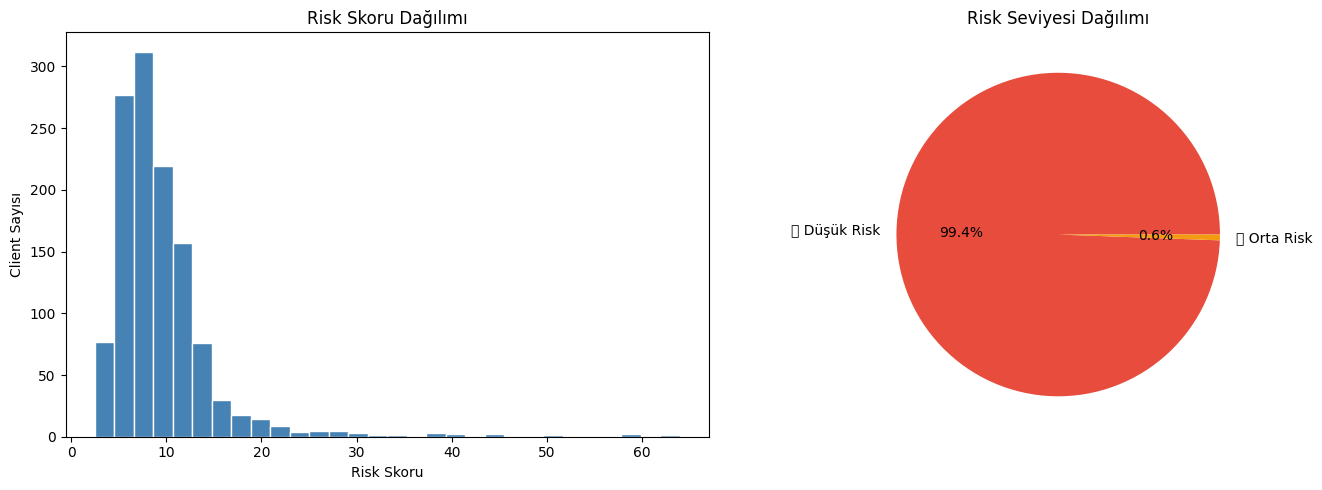

✅ Risk skorları kaydedildi!
risk_seviyesi
🟢 Düşük Risk    1212
🟡 Orta Risk        7
Name: count, dtype: int64


In [3]:
# Risk dağılımı grafiği
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(client_df['risk_skoru'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Risk Skoru Dağılımı')
axes[0].set_xlabel('Risk Skoru')
axes[0].set_ylabel('Client Sayısı')

# Risk seviyesi pasta
risk_counts = client_df['risk_seviyesi'].value_counts()
colors = ['#e74c3c','#f39c12','#2ecc71']
axes[1].pie(risk_counts.values, labels=risk_counts.index, autopct='%1.1f%%', colors=colors)
axes[1].set_title('Risk Seviyesi Dağılımı')

plt.tight_layout()
plt.savefig('../outputs/risk_dagilim.png', dpi=150)
plt.show()

# Kaydet
client_df.to_csv('../data/client_risk.csv', index=False)
print("✅ Risk skorları kaydedildi!")
print(client_df['risk_seviyesi'].value_counts())